# Inductive biases

Inductive bias is the set of assumptions a model makes to generalize beyond the training data. Good biases match the structure and symmetries of your data, yielding better sample efficiency and robustness. Here are few examples of inductive biases to consider:


| Domain / Data Type                 | Key Property / Symmetry                        | Typical NN                     | Inductive bias                                                                                                     |
| ---------------------------------- | ---------------------------------------------- | ---------------------------------- | ----------------------------------------------------------------------------------------------------------------------- |
| Images                             | Local stationarity; translation symmetry; pixel-to-pixel correlations       | **CNN**                            | Captures repeating local patterns;  translation equivariance. |
| Time series          | Causality; temporal order; long correlations | **RNN / GRU / LSTM**               | Recurrent state summarizes history; gating mitigates vanishing/exploding gradients; data-efficient.                     |
|  |                 | **Transformer**           | Self-attention models long dependencies in parallel; order via positional encodings.                                    |
| Graphs                             | Permutation symmetry; relational locality      | **GNN** | Neighbor aggregation is permutation-invariant and respects topology; scalable via sampling.                             |



# Convolutional neural networks





## Convolutional layer

### Convolution operation

We start by introducing the convolution operation, i.e. the operation that is performed to compute the activations of a convolutional layer. For simplifity, we will consider here a 2D convolution (i.e. inputs are always 2D images / tensors). The convolution has two input matrices: the input matrix $I$ of dimension $(d_x, d_y)$ and the *convolution kernel* or *filter* $K$ of dimension $(h,w)$. In the simplest case, we compute the convolved image, $I∗K$, by overlaying the kernel on top of the image in all possible ways, and recording the sum of element-wise products between the image and the kernel:

\begin{equation}
(I * K)_{xy} = \sum_{i=1}^{h} \sum_{j=1}^{w} K_{ij} \, I_{x+i-1,\,y+j-1}
\end{equation}

Here is a visual representation of the previous operation:

::: {#fig-cnn}
<img src="../../figures/cnn_ibm.png" width="60%"/>

Convolution operation. Credit: [IBM](https://www.ibm.com/think/topics/convolutional-neural-networks).
:::

It is important to see that a convolution effectively changes the dimension of our input matrix. In particular, for the case above, the resulting matrix is shrunk from $(d_x\times d_y)$ to $(d_x - w + 1\times d_y - h + 1)$. While this may be a problem, we will show some methods to avoid this shrinkage.


By looking at the above equation, we can see that we are just performing a linear operation, hence not fulfilling the constraints needed to construct a universal approximator. We need to introduce now a non-linear function $\sigma$, which is typically applied per element to the previous matrix. With such, a convolutional layer is defined as:

\begin{equation}
\textrm{conv}(I, K) = \sigma((I * K)_{xy} + b)
\end{equation}

where we also introduced a bias $b$, in this case a matrix of same dimension as the output matrix $(I * K)_{xy}$. Since all we are doing here is addition and scaling of the input pixels, the parameters of the kernels $K_{ij}$ and biases $b_{ij}$ may be learned from a given training dataset via gradient descent, exactly as we did in previous neural networks. These are the trainable *parameters* of a convolutional neural network.


### Convolutional layers hyperparameters
From the previous core operation arise a few implementation choices:

- **Kernel size:** this refers to the width $w$ and height $h$ of the kernel. A larger kernel size allows the convolution to capture broader, more global correlations in the input, while a smaller kernel focuses on fine-grained, local patterns. Thus, kernel size determines the receptive field and the spatial scale of features the network can learn.
- **Depth or channels:** channels refer to a new third dimension of the 2D matrices used above. For the input image, this relates for instance to the color channels (hence depth 3). It also relates to the *number of kernels*. Let's see an example with the following network:

::: {#fig-cnn-channels}
<img src="../../figures/cnn_diagram.svg" width="60%"/>

Convolutional layers with channels. Adapted from [d2l.ai](d2l.ai).
:::
    
Let's focus on the third dimension only here and go step by step:
1. The input has a single channel, hence dimension 1.
2. We now apply a convolution with a kernel size $(5\times5)$. But instead of considering a single kernel, I will stack 16 of them. Importantly, these kernels have their own training parameters and are independent of each other. Because I have 16 kernels, applying the convolution operation above leads to 16 different matrices, which we stacked for an output matrix of size $(13\times13\times16)$.
3.  We now apply again a convolutional layer, now with filters of size $(3\times3)$. Importantly, the third dimension of the input matrix must coincide with that of the kernel. So actually, our kernels are now three dimensional tensors of size $(3\times3\times16)$. In general, given an input matrix $I_{d_xd_yc}$ and a kernel $K_{whc}$, we are performing:
   \begin{equation}
    (I * K)_{xy} = \sum_{i=1}^{h} \sum_{j=1}^{w} \sum_{k=1}^{c} K_{ijk} \, I_{x+i-1,\,y+j-1,k}
    \end{equation}
   In the following picture we can see this operation:
    
    
::: {#fig-cnn-channels-simp}
<img src="../../figures/cnn_channels.svg"  width="40%"/>

Convolution operation with channels. Adapted from [d2l.ai](d2l.ai).
:::

- **Stride:** refers to the displacement we make when convolving the images. Until now, we have considered a stride of one, but in many cases we may consider a bigger one, as shown here:

::: {#fig-cnn-dims}
<img src="../../figures/cnn_stride.svg"  width="30%"/>

Stride in convolutions
:::

- **Padding:** One problem of the convolution operation is that it effectively reduces the size of the output matrix. This also introduces a disparity on how much each element of the input matrix is used when performing the convolution. For instance, the corner elements are only used once, hence barely contributing to the output. To solve both problems, we consider padding: we add extra pixels around the boundary of our input image, thus increasing the effective size of the image. Typically, we set the values of the extra pixels to zero, although this is also sometimes a key hyperparameter. The following image showcases its effect:

::: {#fig-cnn-dims}
<img src="../../figures/cnn_padding.svg"  width="60%"/>

Padding in convolutions. Adapted from [d2l.ai](d2l.ai).
:::
  As we can see, our input matrix was of dimension $(3\times3)$. From the example in @#fig-cnn-channels, we see that without padding, the output dimension would have been reduced to $(2\times2)$. In contrast, our output matrix has now increased dimension, allowing us to create deeper convolutional neural networks without worrying about reducing the dimension!
  The value of the padding can be set at will, but should not be smaller than the kernel size, as if not we will have elements of the output matrix that are just zero.

- **Output dimensions of the convolution:** depending on the parameters above, the output dimension may vary drastically. It is hence important to keep track of the dimensions after each layer. Considering again an input matrix $I$ of dimension $(d_x, d_y)$ and the filter $K$ of dimension $(h,w)$, a stride $s$ and a padding of $p$, the output dimension is given by:

\begin{aligned}
d_x' &= \left\lfloor \frac{d_x - w + 2p}{s} \right\rfloor + 1, \\
d_y' &= \left\lfloor \frac{d_y - h + 2p}{s} \right\rfloor + 1.
\end{aligned}
    
 Typically, `pytorch` and other libraries will take care of this for us, but during debugging it's always helpful to keep this in mind!

### Convolution operation with `pytorch`
Let's put in practice the previous concepts with `pytorch`. We first explore how to do a simple convolution: 

In [ ]:
import torch

dx, dy = 6, 8
# IMPORTANT: the first dimension corresponds to the number of channels and must be always specified, even when equal to 1
I = torch.rand((1, dx,dy))

h, w = 3, 4
conv = torch.nn.Conv2d(in_channels = 1, # We are considering here a 2D matrix, so just one channel
                    out_channels = 1, # This refers to the number of kernels, let's keep at 1 and comeback to it later
                    kernel_size = (h,w))

# Now we perform the convolution of I w.r.t. m. m behaves as a layer, so we can just do:
O = conv(I)

# Let's look at the output and its shape
O, O.shape

(tensor([[[ 0.1258,  0.0408,  0.0807, -0.0756,  0.1093],
          [ 0.0870, -0.1156,  0.2318, -0.0272, -0.0154],
          [-0.0612, -0.1874,  0.0068, -0.0847,  0.0821],
          [ 0.2037,  0.0611, -0.0760, -0.0411,  0.0485]]],
        grad_fn=<SqueezeBackward1>),
 torch.Size([1, 4, 5]))

In this previous example we kept the number of kernels (`out_channels` input variable) at one. We can set this at will. Moreover, `pytorch` we take into account the input dimensionality when creating the kernels. Let's for instance reproduce the example we saw in @fig-cnn-channels

In [ ]:
I = torch.rand((1, 28, 28))

conv1 = torch.nn.Conv2d(in_channels = 1, # the input is still 1
                        out_channels = 16, # we now consider 16 kernels
                        kernel_size = (5, 5))

conv2 = torch.nn.Conv2d(in_channels = 16, # because the previous out is 16, we consider that as input
                        out_channels = 2, # we now consider 2 kernels
                        kernel_size = (3, 3))

# Now we can compute the convolutions:

out1 = conv1(I)
print(f'Dimension after 1st conv: {out1.shape}')

out2 = conv2(out1)
print(f'Dimension after 2nd conv: {out2.shape}')

Dimension after 1st conv: torch.Size([16, 24, 24])
Dimension after 2nd conv: torch.Size([2, 22, 22])


In the same way, we can introduce padding and stride easily:

In [ ]:
I = torch.rand((1, 28, 28))

conv_pad_str = torch.nn.Conv2d(in_channels = 1,
                                 out_channels = 16,
                                 kernel_size = (5, 5),
                                 stride = 3,
                                 padding = 4
                                )
conv_pad_str(I).shape

torch.Size([16, 11, 11])

You can play with the numbers above to get an idea on how these parameters interplay.

### Pooling operation
Pooling layers reduce the spatial dimensions of feature maps by summarizing local regions, typically using operations like max or average. This downsampling helps make the network more computationally efficient and robust to small spatial translations or distortions. Let's see an example: 

::: {#fig-cnn-maxpool}
<img src="../../figures/cnn_maxpool.png"  width="70%"/>

Pooling layer example. The pooling above considers a stride of 2.
:::

Pooling layers are defined by the size $(f_x\times f_y)$ of their feature maps, i.e. the size of a region from which a result is pooled, and the stride $s$, which works just for convolutional layers. Consider again an input matrix of dimensions $(d_x\times d_y)$, the output size is given by

\begin{aligned}
d_x' &= \left\lfloor \frac{d_x - f_x}{s} \right\rfloor + 1, \\
d_y' &= \left\lfloor \frac{d_y - f_y}{s} \right\rfloor + 1,
\end{aligned}

In @fig-cnn-maxpool we considered a max pooling operation, although other pooling operations exist: 
- Max pooling: computes the maximum of the feature map
- Average pooling: computes the average of the feature map
- Global Pooling: this is an special operation, which reduces each channel of the feature map to a single value. For instance, if our matrix is of size $(d_x\times d_y\times d_c)$, performing gobal pooling would transform it to a matrix $(1\times 1\times d_c)$. It is analog to considering a a feature map of size $(d_x\times d_y)$. Again, both the max or average operations can be considered.

This type of layer is particularly useful at then end of our convolutional neural network, to help us flatten the tensors in a robust way, able to backward pass gradients. Let's first see an example of max and average pooling: 

In [ ]:
I = torch.rand((1, 6,6))

max_pool = torch.nn.MaxPool2d(3, stride=2)

avg_pool = torch.nn.AvgPool2d(3, stride=2)

max_pool(I), avg_pool(I)

(tensor([[[0.9925, 0.8997],
          [0.8536, 0.8997]]]),
 tensor([[[0.6202, 0.4331],
          [0.5649, 0.4556]]]))

Pytorch does not have a built-in global pooling layer, but we can built it ourselves by considering the dimensions of the input matrix:

In [ ]:
I = torch.rand((15,6,6)) # Let's consider few channels

global_pool = torch.nn.MaxPool2d(I.shape[-2:]) # We consider a feature map with size the last two dimensions of input matrix

global_pool(I).shape

torch.Size([15, 1, 1])

## Architectures
We will now explore few different architectures we can build based on convolutional layers.

### Creating a CNN with pytorch
We will start by using `pytorch`'s modules to create a CNN. It works just as with the feed forward layers. We will consider that our input images are grayscale, i.e. a single input channel. Note that because of the nature of convolutional layer, we do not care about the other dimensions, and our network would in principle work fine with any one channel image. 

In [ ]:
import torch.nn.functional as F

class ConvNN(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = torch.nn.Conv2d(in_channels = 1, # we get greyscale images (one channels)
                                     out_channels = 16, # we now consider 16 kernels
                                     kernel_size = 5)
        
        self.conv2 = torch.nn.Conv2d(in_channels = 16, # because the previous out is 16, we consider that as input
                                     out_channels = 12, # we now consider 12 kernels
                                     kernel_size = (3, 3))
        
        # Let's also add a final linear layer to get the desider output shape, let's say for this example 5.
        # Because our last conv layer has 12 channels, we can later implement a global pooling and end up
        # with a tensor of single dimension and shape 12. This gives us the shape our linear layer should have:
        self.linear_1 = torch.nn.Linear(12, 5)
        
    def forward(self, x):
        z = self.conv1(x)
        x = F.relu(z)
        z = self.conv2(x)
        x = F.relu(z)
        # Now we implement the global pooling. Because we may not know the dimensions of the input matrix,
        # we calculate them on the flight
        x = torch.nn.MaxPool2d(x.shape[-2:])(x)   
        # We can get rid of the "spurious" dimensions (those equal to one) using the squeeze function
        x = x.squeeze()
        
        z = self.linear_1(x)
        # we can decide or not to perform an activation function here :)
        return z 
    

In [ ]:
# Let's define our model
model = ConvNN()

# And test it with a batch of 64 images of dimension (32x32)
batch = torch.rand((64, # batch size
                    1, # num channels
                    32, # dx
                    32 #dy
                   ))

out = model(batch)
out.shape

torch.Size([64, 5])

::: {.callout-note}
The max pooling operation shown above is often too aggressive for most applications, as it tends to oversimplify the feature maps. Instead, it is more common to apply max pooling over a single dimension and then flatten the resulting output before feeding it into a linear layer.

In [ ]:
class ConvNN_pooling(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv = nn.Conv2d(1, 16, 5)
        # Maxpool only on second dim
        self.pool = nn.MaxPool2d(2)
        self.flatten = nn.Flatten()

        # This lazy linear computes the input dimension on the first pass of the network, 
        # so we don't need to input it!
        self.fc = nn.LazyLinear(out_features=10) 

    def forward(self, x):
        
        x = self.conv(x)
        x = self.pool(x)
        x = self.flatten(x)        
        x = self.fc(x)
        
        return x

ConvNN_pooling()(torch.rand((1,1,28,28))).shape

torch.Size([1, 10])

:::

::: {.callout-tip}
## Exercise

Using both convolutional, pooling and any other layer you want, create a CNN and train it to classify MNIST as we did in the section "Deep learning à la torch" in [this notebook](02_nn_with_pytorch.ipynb).Can you improve those results? Plot the accuracy and check that it is higher than for the feed forward network (FNN).

**Bonus:** when comparing NN, it is important to keep the number of parameters equal. This makes the comparison fairer, as the advantage will not arise from having a more powerful network (more parameters) but rather on its inductive bias. Based on the maths we learned through this notebook and in previous, create two networks, one based on linear layers and one based on convolutional layers, with (approximately) the same number of parameters. I recommend that you first find a CNN that works, check the number of parameters, and then scale down the size of th FNN. You can check the number of trainable parameters (and more info!) from a `torch.nn.Module` installing the library `pip install torchsummary` and using:

In [ ]:
from torchsummary import summary
summary(model = ConvNN_pooling(), input_size = (1,32,32), device = 'cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             416
         MaxPool2d-2           [-1, 16, 14, 14]               0
           Flatten-3                 [-1, 3136]               0
            Linear-4                   [-1, 10]          31,370
Total params: 31,786
Trainable params: 31,786
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.14
Params size (MB): 0.12
Estimated Total Size (MB): 0.27
----------------------------------------------------------------


Then retrain on MNIST and compare.
:::

# Recurrent Neural Networks (RNNs)

While Convolutional Neural Networks excel at processing spatially structured data, **Recurrent Neural Networks (RNNs)** are designed for **sequential data**, where order and temporal dependencies matter — such as time series, text, or trajectories.

RNNs embody an **inductive bias of temporal recurrence**: the assumption that the current state depends on a summary of all past inputs. Concretely, they aim to model data that follow an **autoregressive factorization**:

\begin{equation}
p(x) = \prod_t p(x_t \mid x_{t' < t})
\end{equation}

In this view, each element $x_t$ is generated conditionally on the history of previous elements. As we will see, RNNs retain and propagate information over time through a *hidden state*, making them a natural architecture for modeling temporal correlations and sequential dynamics.

## Recurrent layer

In @fig-rnn you can see a high-level representation of an RNN:

::: {#fig-rnn}
<img src="../../figures/rnn_fold_unfold.svg" width="70%"/>

Schematic representation of an RNN. Adapted from [d2l.ai](d2l.ai).
:::

> **Note:** for simplicity, we will not explicitly show biases in the following formulation.

From the rolled diagram on the left, you can see that the RNN receives an input $X$, typically a sequence, and after processing it through its hidden layer, predicts an output $Y$, which is also a sequence.  To understand what happens inside the RNN, let's *unroll* it (right diagram). We divide the input sentence into its elements $x_1, x_2, \ldots, x_T$. These are fed to the network sequentially. As shown, each hidden layer produces two outputs: the hidden state $h_t$ and the actual output $y_t$. This internal or hidden state propagates through time, carrying information from past inputs into future predictions.  

The recurrent layer can then be expressed as the recurrence relation:

\begin{equation}
h_t = f_W(h_{t-1}, x_t),
\end{equation}
where $f_W$ is a parameterized function, i.e., one with learnable weights.  In a typical RNN, the hidden state is computed as:

\begin{equation}
h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t)
\end{equation}
where $W_{hh}$ and $W_{xh}$ are weight matrices. Importantly, all layers share the same weights — allowing the RNN to handle sequences of arbitrary length, since the same parameters are reused at each time step.  We use here a hyperbolic tangent as the nonlinear activation to keep the values of the hidden state bounded between $[-1, 1]$.

From this hidden state, we can compute the output at a given time step as:
\begin{equation}
y_t = W_{hy} h_t,
\end{equation}
where $W_{hy}$ is another weight matrix shared across all time steps.  
As you can see, the output depends on $h_t$, which itself depends on the current input $x_t$ and the previous hidden state $h_{t-1}$.   This ensures that each output reflects both the information at the current time step and the history of past inputs.

Let's take a look at how an RNN is implemented in `PyTorch`:


In [ ]:
# It already built-in in pytorch!
rnn = torch.nn.RNN(input_size = 4, # Number of features of the input sequence (e.g. x and y position, temperature and mass for a given particle)
                   hidden_size = 2, # Size of the hidden state 
                   batch_first=True) # Allows us to put batch dimension first as in convolutions (optional)

# We define now a single input sequence (BS=1), of length 10, and with the 4 expected features
x = torch.randn(1, 10, 4)

# We can now perform a forward pass through the RNN:
out, hn = rnn(x)

print("Input shape:", x.shape)
print("Output 1 shape:", out.shape)   
print("Output 2 shape:", hn.shape)

Input shape: torch.Size([1, 10, 4])
Output shape: torch.Size([1, 10, 2])
Hidden state shape: torch.Size([1, 1, 2])


As you can see, the output `out` of `rnn` is actually of `(batch, seq_len, hidden_size)`. This is because `pytorch` is not calculating the last linear layer (`y = W_{hy} h`), but giving us directly `h`. The second output `hn` is the last hidden state, i.e. $h_T$. Let's then compute the actual output $y$ ourselves:

In [ ]:
rnn = torch.nn.RNN(input_size = 4, # Number of features of the input sequence (e.g. x and y position, temperature and mass for a given particle)
                   hidden_size = 2, # Size of the hidden state 
                   batch_first=True) # Allows us to put batch dimension first as in convolutions (optional)
# Input
x = torch.randn(1, 10, 4)

# Output
h, hn = rnn(x)

# Linear layer: as an example, we go from the previous hidden size of 2 to the same input dimensions (4 features)
linear = torch.nn.Linear(2, 4)

y = linear(h)

print("Y shape:", y.shape)

Y shape: torch.Size([1, 10, 4])


You can now see that the shape matches the expected! As commented above, the same RNN can be used for any sequence length:

In [ ]:
# Let's consider now a much longer sequence. Note that feature number must stay the same:
x = torch.randn(1, 100, 4)

# We can also predefine a hidden layer and feed it to the rnn!
ht = torch.randn((1, 1, 2))

# Again the forward pass:
out, hn = rnn(x, ht)

print("Input shape:", x.shape)
print("Output shape:", out.shape)   # (batch, seq_len, hidden_size)
print("Hidden state shape:", hn.shape)

Input shape: torch.Size([1, 100, 4])
Output shape: torch.Size([1, 100, 2])
Hidden state shape: torch.Size([1, 1, 2])


As expected, the output size changes with input size, while the hidden state shape stays the same.

### Vanishing gradients in RNNs
One of the key problems of RNNs is their vanishing gradient for longer sequences. Let's consider a loss function $L=\sum_{t=0}^T L_t$, i.e. the loss is computed per time step (a very reasonable assumption and common in this type of problems). Now, let's compute the gradient w.r.t. to $W_{hh}$:

\begin{equation}
\frac{\partial L_t}{\partial W_{hh}} 
= \frac{\partial L_t}{\partial h_t}
   \frac{\partial h_t}{\partial h_{t-1}}
   \cdots
   \frac{\partial h_1}{\partial W_{hh}}
= \frac{\partial L_t}{\partial h_t}
   \left( \prod_{t=2}^{T} 
      \frac{\partial h_t}{\partial h_{t-1}}
   \right)
   \frac{\partial h_1}{\partial W_{hh}}.
\end{equation}

If we now compute $\frac{\partial h_t}{\partial h_{t-1}}$, we get

\begin{equation}
\frac{\partial h_t}{\partial h_{t-1}} 
= \tanh'\!\left(W_{hh} h_{t-1} + W_{xh} x_t\right) W_{hh}.
\end{equation}

Because $0<\tanh'(x)<1$ for all $x$, we see that the product in the above equation decays exponentially with the sequence length! This is bad, as the effect of $W_{hh}$ over outputs beyond a certain length will be zero, meaning no update... 

Before checking solutions, let's see this programatically:

In [ ]:
#| code-fold: true
torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu' # This line will select cpu is cuda is not available!

# We define a simple RNN as aboce
rnn = nn.RNN(input_size = 1, hidden_size = 5, batch_first=True, nonlinearity='tanh').to(device)

# Let's consider input lengths from 2 to 100
seq_lengths = torch.arange(2,100).to(int)

gradients_Whh = []

for L in tqdm(seq_lengths):
    
    # We just define a dummy input, we don't care too much on its value
    # because it does not enter in the gradient calculation (see equation
    # above).
    x = torch.zeros(1, L, input_size, device = device)

    # We initialize a random gaussian hidden state
    h0 = torch.randn(1, 1, hidden_size, requires_grad=True, device = device)

    out, hn = rnn(x, h0)     

    # Simple MSE loss depending only on the last output
    last_out = out[:, -1, :]    
    loss = (last_out - torch.rand_like(last_out)).pow(2).sum()

    # Backprop
    rnn.zero_grad()
    if h0.grad is not None:
        h0.grad.zero_()
    loss.backward()
 
    gradients_Whh.append(h0.grad.norm().item())


  0%|          | 0/98 [00:00<?, ?it/s]

Text(0, 0.5, '|$\\frac{\\partial L}{\\partial h_t}|$')

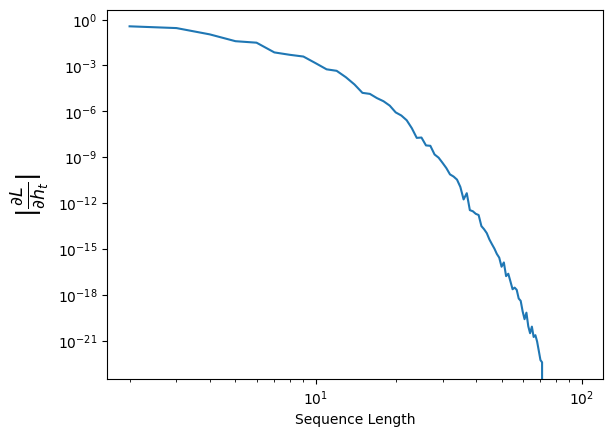

In [ ]:
#| code-fold: true
#| code-summary: Figure code

plt.loglog(seq_lengths, grad_norms_h0)
plt.xlabel('Sequence Length')
plt.ylabel(r'|$\frac{\partial L}{\partial h_t}|$', fontsize = 18)

## Long short term memory (LSTM)

As we have seen, a major limitation of vanilla RNNs is the **vanishing (or exploding) gradient problem**, which makes it difficult for them to learn long-term dependencies. To overcome this, **Long Short-Term Memory (LSTM)** networks introduce a more sophisticated recurrent cell that includes *gates* controlling the flow of information. These gates enable the network to preserve, update, or forget information over long sequences through an **additive memory path**, rather than a purely multiplicative one. As a result, LSTMs can maintain stable gradients and effectively capture long-range temporal dependencies in sequential data. A LSTM cell neuron looks like:

::: {#fig-lstm}
<img src="../../figures/lstm.svg"  width="70%"/>

Schematic representation of an LSTM. Adapted from [d2l.ai](d2l.ai).
:::

As you can see, it's much more complex than before. The main addition is the introduction of a new hidden state called the **memory cell state**. This new state helps carry information across different time steps and mitigates the **vanishing gradient problem**. However, some aspects remain the same. For instance, the output is still computed from the hidden state, namely:

\begin{equation}
y_t = W_{hy} h_t
\end{equation}

Let's now understand how the input is transformed through the *gates* $\sigma$ (blue, yellow, and green). All these gates apply a sigmoid function to the input, thus mapping their values to the range $[0,1]$.  Each gate has its own purpose:

- **Forget gate:** Determines how much of the current cell state should be forgotten.  
- **Input gate:** Determines how much of the new input should be added to the cell state.  
- **Output gate:** Determines how much of the cell state should influence the output hidden state.  



Next comes the **input node**. This component works just like in a standard RNN: we compute a parameterized function of the input followed by a $\tanh$ activation.  
Once this is done, we can update the **memory cell state** as:

\begin{equation}
c_t = F_t \cdot C_{t-1} + I_t \cdot \tilde{C_t}
\end{equation}

This **additive update** is the key innovation that allows LSTMs to overcome the *vanishing gradient problem*.  
Unlike the purely multiplicative recurrence of vanilla RNNs, here the gradient flows through an almost linear path:

\begin{equation}
\frac{\partial c_t}{\partial c_{t-1}} = F_t
\end{equation}

When the forget gate $F_t$ remains close to 1 (i.e., when the network *chooses not to forget*), gradients can propagate backward through many time steps without diminishing, effectively creating a **“gradient highway”** that preserves long-term dependencies.  

Finally, we compute the **output hidden state** as:

\begin{equation}
h_t = O_t \cdot \tanh(c_t)
\end{equation}

Now that we understand the theory behind an LSTM, let's see how to implement it in `PyTorch`. As you’ll see below, it works almost exactly like an RNN: we just need to keep track of the **cell state** in addition to the hidden state!


In [ ]:
# It’s also built-in in PyTorch!
lstm = torch.nn.LSTM(input_size = 4,   # Number of input features at each time step
                     hidden_size = 2,  # Size of the hidden (and cell) state
                     batch_first = True)  # (batch, seq, feature) format

# Define a single input sequence (batch_size = 1), sequence length = 10, features = 4
x = torch.randn(1, 10, 4)

# Perform a forward pass through the LSTM
# It returns both the sequence of outputs and the final hidden & cell states
out, (hn, cn) = lstm(x)

print("Input shape:", x.shape)
print("Output shape:", out.shape)   # (batch, seq_len, hidden_size)
print("Hidden state shape:", hn.shape)  # (num_layers, batch, hidden_size)
print("Cell state shape:", cn.shape)    # (num_layers, batch, hidden_size)


Input shape: torch.Size([1, 10, 4])
Output shape: torch.Size([1, 10, 2])
Hidden state shape: torch.Size([1, 1, 2])
Cell state shape: torch.Size([1, 1, 2])


Now let's demonstrate numerically that the forget gate actually helps us propagate the gradients no matter the sequence lenght. For that, we will define an `LSTM` layer, and manually set the bias of the forget gate. Note that the bias is going to affect the activation, which then will go through the activation function $\sigma$, always bounded in $[0,1$].

In [ ]:
#| code-fold: true

torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

input_size  = 1
hidden_size = 5
seq_lengths = torch.arange(2, 100)

# Let's now consider different forget bias (0 would mean we forget everything, >>0 we do not) 
forget_biases = [0, 0.5, 1, 1.5, 2]
grads_c0_bias = torch.zeros((len(forget_biases), seq_lengths.shape[0]))

for idxb, forget_bias in enumerate(tqdm(forget_biases)):

    # We define the LSTM layer
    lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True).to(device)

    # And now manually change the bias of the Forget's gates biases
    with torch.no_grad():
        # Gate order in PyTorch LSTM is (i, f, g, o)
        for name in ['bias_ih_l0', 'bias_hh_l0']:
            b = getattr(lstm, name)
            b[hidden_size:2*hidden_size] += forget_bias # add +forget_bias to forget gate slice    
    
    grads_c0 = []
    
    for idxl, L in enumerate(seq_lengths):
        # Zero input so recurrence dominates
        x = torch.zeros(1, L, input_size, device=device)
    
        # Initial states (enable gradients!)
        h0 = torch.randn(1, 1, hidden_size, device=device, requires_grad=True)
        c0 = torch.randn(1, 1, hidden_size, device=device, requires_grad=True)
    
        out, (hn, cn) = lstm(x, (h0, c0))
    
        # Loss only on the LAST output to force long-range backprop
        last_out = out[:, -1, :]
        loss = (last_out - torch.rand_like(last_out)).pow(2).sum()
    
        # Backprop
        lstm.zero_grad()
        if c0.grad is not None: c0.grad.zero_()
        loss.backward()
    
    
        grads_c0.append(c0.grad.norm().item())

    grads_c0_bias[idxb] = torch.tensor(grads_c0)

  0%|          | 0/5 [00:00<?, ?it/s]

Text(0, 0.5, '$|\\frac{\\partial L}{\\partial c_0}|$')

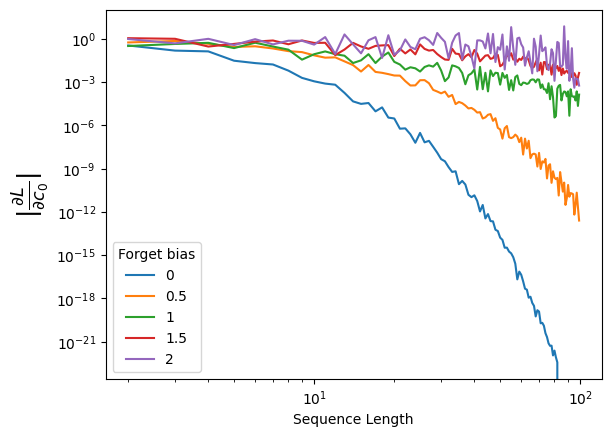

In [ ]:
#| code-fold: true
#| code-summary: Figure code

for line, bias in zip(grads_c0_bias, forget_biases):
    plt.loglog(seq_lengths, line, label = bias)
plt.legend(title = 'Forget bias')
plt.xlabel('Sequence Length')
plt.ylabel(r'$|\frac{\partial L}{\partial c_0}|$', fontsize=18)

As we can see, when the forget gate takes values close to 0, we recover the same regime as in vanilla RNNs, where gradients quickly vanish.  However, when the bias is larger and the forget gate remains close to 1, the gradients are preserved. Since the forget gate is learned, the network can autonomously decide whether long-range information is important and should be retained or forgotten.  

Nevertheless, even with a bias of 2, a slight decrease in the gradients can still be observed. This occurs because the vanishing gradient problem is not completely eliminated by the forget gate, although its effect is significantly reduced.  

## Deep RNN

So far, we have considered RNNs with a single recurrent layer. In a **deep RNN**, multiple recurrent layers are stacked on top of each other, so that each layer processes the entire output sequence of the previous one. This hierarchical structure allows the network to build progressively more abstract temporal representations: the lower layers capture short-term dynamics, while the higher layers integrate information over longer time scales.  Deep RNNs therefore combine the temporal modeling power of recurrence with the feature hierarchy typical of deep feed-forward networks. A typical deep RNN would look like:

::: {#fig-deep-rnn}
<img src="../../figures/deep-rnn.svg"  width="30%"/>

Schematic representation of an deep RNN. Adapted from [d2l.ai](d2l.ai).
:::


#### Classification / Regression with RNN

Building on the previous concepts, we can now create a **deep neural network** by stacking multiple RNN layers.  Instead of having to do this “by hand,” as we did with linear and convolutional layers, `PyTorch` allows us to specify the number of layers directly as an input argument.  

As before, we will add a final linear layer to map the hidden state to the desired output. Importantly, in many applications, we are not interested in producing an output sequence, but rather a single scalar or logit representing the result of a regression or classification task.  There are several ways to obtain such a scalar output, as the sequence can be summarized in multiple ways.  The simplest and most robust approach is to take the **last output element**, since the RNN has already compressed the temporal information up to that point. We then add an additional linear layer to increase the model’s expressive power.

Let's do all this within a `tor.nn.Module`:

In [ ]:
class DeepRNN(nn.Module):
    def __init__(self, input_size: int, 
                 hidden_size: int, 
                 num_layers: int, 
                 output_size: int,
                 batch_first: bool = True):
        super().__init__()

        # Let's keep track of how many layers we have!
        self.num_layers = num_layers

        # We first define the RNN with multiple layers
        self.rnn = nn.RNN(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=self.num_layers,
                          nonlinearity='tanh',
                          batch_first=batch_first)
        
        # And now the linear layer. We will take the last value of the output of the last layer, which will be size (BS, hidden_size)
        self.readout = nn.Linear(hidden_size, output_size) 

    def forward(self, x, h0=None):
        # x: (B, T, input_size) if batch_first=True
        out, hn = self.rnn(x, h0)          # out: (B, T, hidden_size)
        
        # Now let's consider only the last temporal element of the last layer
        z = hn[-1:].squeeze(0)           # z:  (B, hidden_size)

        # And pass it through a last linear layer
        y = self.readout(z).squeeze()   # y:  (B)
        return y


In [ ]:
deep_rnn = DeepRNN(input_size = 4,
                   hidden_size = 5,
                   num_layers = 3,
                   output_size = 1) # We want to do regression, so only one output per sample

# We define now a batch of 64 input sequences, of length 10, and with the 4 expected features
x = torch.randn(64, 10, 4)

# We can now perform a forward pass through the RNN. It will return both the out and its internal state.
out = deep_rnn(x)

print("Input shape:", x.shape)
print("Output shape:", out.shape)   # (batch, seq_len, output_size)

Input shape: torch.Size([64, 10, 4])
Output shape: torch.Size([64])


### Bidirectional RNN

A limitation of standard RNNs is their **directionality**: information flows only forward in time, meaning each hidden state depends solely on past inputs. This makes it impossible for the model to incorporate *future context* when predicting the current output.  **Bidirectional RNNs (BiRNNs)** address this by processing the sequence in both directions: one RNN runs forward, another runs backward, and their hidden states are combined at each time step.  
As a result, the network can exploit dependencies from both the past and the future, which is particularly advantageous in tasks like speech recognition, text analysis, or any problem where the full sequence is available beforehand.

::: {#fig-deep-rnn}
<img src="../../figures/birnn.svg"  width="40%"/>

Schematic representation of an bidirectional RNN. Adapted from [d2l.ai](d2l.ai).
:::


As you can see above, it works almost the same way as a RNN, but we have a set of connections on the opposite direction. There is also a key difference: the output is now calculated from the concatenation of the hiddent states of both layers:

\begin{equation}
y_t = W_o 
\begin{bmatrix}
\overrightarrow{h_t} \\
\overleftarrow{h_t}
\end{bmatrix}
+ b_o
\end{equation}


In [ ]:
class BiRNN(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_layers: int, output_size: int, batch_first: bool = True):
        super().__init__()

        # Define a bidirectional RNN
        self.rnn = nn.RNN(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          nonlinearity='tanh',
                          batch_first=batch_first,
                          bidirectional=True)
        
        # Because it's bidirectional, output features = 2 × hidden_size
        self.readout = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x, h0=None):
        # Forward pass through the bidirectional RNN
        out, hn = self.rnn(x, h0)      # out: (B, T, 2*hidden_size)
        y = self.readout(out)          # map combined forward+backward states
        return y, hn


bi_rnn = BiRNN(input_size = 4,
               hidden_size = 5,
               num_layers = 3,
               output_size = 4)

# We define now a batch of 64 input sequences, of length 10, and with the 4 expected features
x = torch.randn(64, 10, 4)

# Forward pass through the bi-RNN
out, hn = bi_rnn(x)

print("Input shape:", x.shape)
print("Output shape:", out.shape)   # (batch, seq_len, output_size)
print("Hidden state shape:", hn.shape) # (num_layers * num_directions, batch, hidden_size)

Input shape: torch.Size([64, 10, 4])
Output shape: torch.Size([64, 10, 4])
Hidden state shape: torch.Size([6, 64, 5])


## Encoder-Decoder architecture

One of the drawbacks of the previous implementations is that we were supposing that the output sequence is of same length of the input. But in most cases this is not the case. For instance, in German-English translation: `See you soon` (3 words) -> `Bis bald` (2 words). This a typical problem in sequence-to-sequence (seq2seq) problems. To solve that in an efficient way, we consider the Encoder-Decoder model below:

::: {#fig-enc-dec}
<img src="../../figures/seq2seq.svg"  width="70%"/>

Encoder-Decoder architecture. Adapted from [d2l.ai](d2l.ai).
:::

> Note: in the previous we are considering that words can be "tokenized", i.e. transformed into continuous vectors. We won't cover this topic in this course, but if you are interested you can take a look at this nice [tutorial](enjoyalgorithms.com/blog/word-vector-encoding-in-nlp).

In this architecture, the encoder processes the input sequence and compresses its information into a fixed-length hidden representation. The decoder then uses this representation to generate the output sequence step by step, allowing input and output lengths to differ. This setup forms the basis of many translation and sequence generation models.

### Inference
The previous scheme considers the *training* of the network. But during *inference*, we won't have access to the German sentence, as it is the one we aim to generate. To solve this, we use the autoregression to iteratively compute the next input from the decoder's output:

::: {#fig-end-dec-inference}
<img src="../../figures/seq2seq-inference.svg"  width="70%"/>

Inference in the encoder-decoder architecture. Adapted from [d2l.ai](d2l.ai).
:::

## Transformers

The last architecture we will review here is one of the biggest cornerstones of the current machine learning field, helping take the Natural Language Processing (NLP) to the level of large language models. We are talking about the Transformer, introduced in the paper [Attention is all you need, Vaswani et al. (2017)](https://arxiv.org/pdf/1706.03762). Unlike RNNs or LSTMs, Transformers do not rely on sequential processing, allowing them to capture long-range dependencies in parallel and greatly speed up training. Their attention mechanism also enables them to focus selectively on the most relevant parts of the input, leading to superior performance on complex language and sequence tasks.

### The attention mechanism
The attention mechanism is at the core of the transformer architecture. To understand how this works, let's consider a simple example with a database $D$. The database contains for instance people's surname and their family name: $D=${("John", "Smith"), ("Erika", "Mustermann")...}. Here the name is the *key*, and the family name its *value*. For simplicity, we can write the database as $D={(k_i,v_i)}_{i=1:N}$, where $N$ is the size of the database. Now we make a *query* $q_j$ to this database. In the exact case, $q_j$ matches exactly one of the keys $k_i$. However, our query may not be in the database, but it may relate closely to some keys. In [Bahdanau et al. (2014)](https://arxiv.org/pdf/1409.0473), the authors introduced the attention mechanism, defined as:

\begin{equation}
\text{Att}(q_j, D) = \sum_{i=1}^N \alpha(q_j, k_i) v_i,
\end{equation}
where $\alpha(q_j, k_i)$ is the attention score / weights between a particular query and key. The name attention derives from the fact that the operation pays particular attention to the terms for which the weight is significant (i.e., large). As such, the attention over generates a linear combination of values contained in the database. 

There are many different ways of computing the attention score, here we will focus on the most used one: the **scaled dot-product attention**, which is simply written as

\begin{equation}
\alpha(q_j, k_i) = \text{softmax}\left( \frac{q_j \cdot k_i}{\sqrt{d_k}} \right),
\end{equation}

where $d_k$ is the dimension of the keys. Note that the previous equation can be calculated for a batch of queries $Q$ and the full $K$ database using the dot product $Q\cdot K^{\intercal}$. This operation is typically known as **cross-attention**, because we compute the attention of a new $Q$ across $K$. Here is a schematic representation of the above operation:

::: {#fig-att-mech}
<img src="../../figures/attention_mechanism.png"  width="20%"/>

Schematic of the attention mechanism. From [Attention is all you need, Vaswani et al. (2017)](https://arxiv.org/pdf/1706.03762)
:::

This scheme introduces a new concept: the *mask*, which is used to control between which elements of $Q$ and $K$ the attention is calculated. This will become more relevant later, when we deal with temporal series.

#### Self-attention
The previous showcases the attention mechanism within a database, but in deep learning we are typically interested in computing $y=f(x)$ from a given input $x$. To do so, we use self-attention: rather than computing attention w.r.t. to a database, we compute it w.r.t. the input itself. This allows the network to create a latent vector ($y$ above) that contains information calculated from pairs of elements across the whole input, hence its suitability to identify complex correlations. In particular, we consider that the keys, queries and values are computed as:

\begin{equation}
K = x W_{k} \hspace{2cm} Q = x W_q \hspace{2cm} V = x W_v
\end{equation}

From here, we can just follow the attention mechanism and end up with a matrix of self-attention weights. 

### The transformer architecture
We now have all the ingredients to look at the full transformer architecture:

::: {#fig-transformer}
<img src="../../figures/transformer_enc-dec.png"  width="50%"/>

Transformer architecture. From [Attention is all you need, Vaswani et al. (2017)](https://arxiv.org/pdf/1706.03762)
:::


Let's dissect the previous architecture. As you see, we have here two blocks (left and right), which correspond to an encoder and a decoder just as we defined above. Let's review each of their components.

#### Encoder 

1. **Input Embedding:** An initial layer that transforms the inputs into the desired form. For instance, in language tasks, it converts words (or *tokens*) into dense numerical vectors.  

2. **Positional Encoding:** Since the attention mechanism itself has no sense of order (i.e., which input element comes first, second, etc.), we add positional information through a *positional encoding*: a function added to each input according to its position. In the original paper, this was defined as:  

   \begin{equation}
   \text{PE}_{(pos,\, 2i)} = \sin\!\left(\frac{pos}{10000^{2i / d_{\text{model}}}}\right),
   \qquad
   \text{PE}_{(pos,\, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i / d_{\text{model}}}}\right)
   \end{equation}

   where $pos$ is the position, $i$ is the dimension index, and $d_{\text{model}}$ is the embedding dimension so that the positional encoding can be correctly summed with the input.  

3. **Keys, Values, and Queries:** The input embeddings are then linearly transformed into keys, values, and queries, as introduced earlier.  

4. **Multi-Head Attention:** A repetition of the attention mechanism over several *heads*, allowing each head to focus on different properties of the input data. Each head has its own learned weights.  

   ::: {#fig-transformer}
   <img src="../../figures/multi-head-attention.png" width="20%"/>
   
   *Multi-head attention.* From [*Attention is All You Need*, Vaswani et al. (2017)](https://arxiv.org/pdf/1706.03762)
   :::  

5. **Add & Norm (1):** Adds a residual connection and applies layer normalization.  

6. **Feed-Forward Network:** Applies two linear layers with a nonlinearity to each position independently.  

7. **Add & Norm (2):** Another residual connection followed by normalization.  

8. **Nx (Stacked Layers):** The encoder repeats this block $N$ times to build deeper representations.  

#### Decoder
The decoder has a very similar architecture, with two small differences:

1. As in the Encoder–Decoder section, the input tokens are shifted to the right, so that the first token is `<bos>` and the decoder can generate the sequence autoregressively.
2. Most importantly, the second attention block takes as input the encoder outputs, which serve as the keys and values (acting like a database) for computing cross-attention with the decoder’s own queries.

### Transformers with `pytorch` 
As with previous layers, we can acces the full Transformer architecture using `torch.nn.Transformer`. However, as you will see in [their documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.Transformer.html), this is neither efficient nor recommended. Moreover, in most physics applications, we don't need the full architecture but rather just the encoder, i.e. a block that transforms an input sequence to a "latent" sequence that can then fed into other layers to get our desired output. The encoder layer is indeed also accesible in `python`:

In [ ]:
# Example input: batch of 2 sequences, each 5 tokens long, with embedding size 16
x = torch.randn(2, 5, 16)

# Define a single Transformer encoder layer
encoder_layer = nn.TransformerEncoderLayer(
    d_model=16,        # embedding dimension
    nhead=4,           # number of attention heads
    dim_feedforward=64 # size of the feed-forward layer
)

# Pass data through the layer
out = encoder_layer(x)

print(out.shape)  # (batch_size, seq_len, d_model)

torch.Size([2, 5, 16])


::: {.callout-tip}
## Exercise
It is time to put in practice what we have learned in this section! Create three networks: one based on RNN, one based on LSTM and one based on the Transformer Encoder, and train it in the classification problem at the end of the [NN with Pytorch](02_nn_with_pytorch.ipynb).

1. First, build the models in such a way that they have a *similar* number of parameters. Use the knowledge you got from the previous to build such networks. See the previous exercise to know how to get the number of trainable parameters from a `torch.nn.Module`

2. Train these models over the same amount of epochs and track the loss. Plot the three curves. What do you see? Is there a particular advantage for any of the models?
:::